In [3]:
!pip install torch --index-url https://download.pytorch.org/whl/cu118


Looking in indexes: https://download.pytorch.org/whl/cu118
  Using cached https://download.pytorch.org/whl/sympy-1.13.1-py3-none-any.whl (6.2 MB)
  Attempting uninstall: sympy
    Found existing installation: sympy 1.13.3
    Uninstalling sympy-1.13.3:
      Successfully uninstalled sympy-1.13.3


In [1]:
import sys
sys.path.append('../../utils/')

In [2]:
from Bias_Variance_Estimator import get_bias_variance_0_1

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [5]:
data = fetch_california_housing()
X,y = data.data,data.target

In [6]:
X

array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
          37.88      , -122.23      ],
       [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
          37.86      , -122.22      ],
       [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
          37.85      , -122.24      ],
       ...,
       [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
          39.43      , -121.22      ],
       [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
          39.43      , -121.32      ],
       [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
          39.37      , -121.24      ]])

In [7]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20,random_state=42)

In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
## Converting to pytorch tensors
X_train_tensor = torch.tensor(X_train,dtype = torch.float32)
y_train_tensor = torch.tensor(y_train,dtype = torch.float32).view(-1,1)
X_test_tensor = torch.tensor(X_test,dtype = torch.float32)
y_test_tensor = torch.tensor(y_test,dtype = torch.float32).view(-1,1)

In [10]:
## Creating dataloaders
train_dataset = TensorDataset(X_train_tensor,y_train_tensor)
test_dataset = TensorDataset(X_test_tensor,y_test_tensor)

train_loader = DataLoader(train_dataset,batch_size=64,shuffle=True)
test_loader = DataLoader(test_dataset,batch_size=64)

In [11]:
## defining the regression model

class RegressionModel(nn.Module):
    def __init__(self,input_dim):
        super(RegressionModel,self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim,64),
            nn.ReLU(),
            nn.Linear(64,32),
            nn.ReLU(),
            nn.Linear(32,1)
        )
    def forward(self,x):
        return self.net(x)

In [62]:
def train_model(model,train_loader,epochs=20,lr=0.001):
    loss = nn.L1Loss()
    optimizer = optim.Adam(model.parameters(),lr=lr)
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for X_batch,y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch)
            l = loss(outputs,y_batch)
            l.backward()
            optimizer.step()
            running_loss+=l.item()*X_batch.size(0) ## stores the entire loss during an epoch

        cur_epoch_loss = running_loss/len(train_loader.dataset)
        print(f"Epoch {epoch+1}, Loss: {cur_epoch_loss:.4f}")

In [13]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
def evaluate_model(model, test_loader):
    model.eval()
    mse_loss = nn.L1Loss()
    total_loss = 0.0
    all_preds=[]
    all_targets = []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            preds = model(X_batch)
            loss = mse_loss(preds, y_batch)
            all_preds.append(preds)
            all_targets.append(y_batch)
            total_loss += loss.item() * X_batch.size(0)
    all_preds = torch.cat(all_preds).squeeze().numpy()
    all_targets = torch.cat(all_targets).squeeze().numpy()

    mse = mean_squared_error(all_targets, all_preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(all_targets, all_preds)
    r2 = r2_score(all_targets, all_preds)
    print(f"MSE:  {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE:  {mae:.4f}")
    print(f"R²:   {r2:.4f}")
    print(f"Test MSE: {total_loss / len(test_loader.dataset):.4f}")


In [14]:
# Instantiate and train
input_dim = X_train.shape[1]
model = RegressionModel(input_dim)
train_model(model, train_loader, epochs=20)

# Evaluate
evaluate_model(model, test_loader)


Epoch 1, Loss: 2.8315
Epoch 2, Loss: 1.1070
Epoch 3, Loss: 1.1644
Epoch 4, Loss: 1.0099
Epoch 5, Loss: 0.9967
Epoch 6, Loss: 0.7795
Epoch 7, Loss: 0.7727
Epoch 8, Loss: 0.7880
Epoch 9, Loss: 0.7137
Epoch 10, Loss: 0.6954
Epoch 11, Loss: 0.6859
Epoch 12, Loss: 0.7002
Epoch 13, Loss: 0.6474
Epoch 14, Loss: 0.6622
Epoch 15, Loss: 0.6719
Epoch 16, Loss: 0.7248
Epoch 17, Loss: 0.6449
Epoch 18, Loss: 0.6533
Epoch 19, Loss: 0.6206
Epoch 20, Loss: 0.6402
MSE:  0.6349
RMSE: 0.7968
MAE:  0.5886
R²:   0.5155
Test MSE: 0.5886


In [4]:
import torch
print(torch.version.cuda)  # CUDA version PyTorch was built with
print(torch.cuda.is_available())  # Should be True if GPU accessible


None
False


In [15]:

estimate_bias_variance(
    model_class=RegressionModel,  # or any nn.Module class
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    num_models=30,
    epochs=20,
    model_kwargs = {'input_dim':X_train.shape[1]},
    loss_fn=nn.L1Loss()
    
)


Training on first resample
epoch 0 loss 1.3002662658691406
epoch 1 loss 0.6963195204734802
epoch 2 loss 0.6592052578926086
epoch 3 loss 0.747621476650238
epoch 4 loss 0.6226146221160889
epoch 5 loss 0.6643015742301941
epoch 6 loss 0.6276584267616272
epoch 7 loss 0.624525785446167
epoch 8 loss 0.6728483438491821
epoch 9 loss 0.5951116681098938
epoch 10 loss 0.5456921458244324
epoch 11 loss 0.7856677770614624
epoch 12 loss 0.4933001399040222
epoch 13 loss 0.5448316335678101
epoch 14 loss 0.5847961902618408
epoch 15 loss 0.6064885854721069
epoch 16 loss 0.516493022441864
epoch 17 loss 0.5451200008392334
epoch 18 loss 0.4935934543609619
epoch 19 loss 0.7418569326400757
Training on first resample
epoch 0 loss 0.7264979481697083
epoch 1 loss 1.503869891166687
epoch 2 loss 0.7401763200759888
epoch 3 loss 0.5780447721481323
epoch 4 loss 1.0792585611343384
epoch 5 loss 0.9422620534896851
epoch 6 loss 0.788731038570404
epoch 7 loss 0.5922401547431946
epoch 8 loss 0.6450628042221069
epoch 9 loss 

E:\Dissertation_bv\regression\MSE\../../utils\Bias_Variance_Estimator.py:134: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\torch\csrc\utils\tensor_new.cpp:281.)
  all_preds_tensor = torch.tensor(all_preds,dtype = torch.float32)


Bias²:    1.0121
Variance: 0.1726
Total error: 1.0820
Bias + Variance: 1.1847


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [4]:
torch.cuda.is_available()

False

In [12]:
## Simple Linear Model
class LinearModel(nn.Module):
    def __init__(self, input_dim):
        super(LinearModel,self).__init__()
        self.fc = nn.Linear(input_dim, 1)
    def forward(self, x):
        return self.fc(x)

In [13]:
## small MLP
class SmallMLP(nn.Module):
    def __init__(self,input_dim):
        super(SmallMLP,self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim,5),
            nn.ReLU(),
            nn.Linear(5,1)
        )
    def forward(self,x):
        return self.net(x)

In [14]:
## mediun mlp
class MediumMLP(nn.Module):
    def __init__(self,input_dim):
        super(MediumMLP,self).__init__()
        self.net=nn.Sequential(
            nn.Linear(input_dim,20),
            nn.ReLU(),
            nn.Linear(20,1)
        )
    def forward(self,x):
        return self.net(x)

In [15]:
## deep MLP
class DeepMLP(nn.Module):
    def __init__(self,input_dim):
        super(DeepMLP,self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim,20),
            nn.ReLU(),
            nn.Linear(20,20),
            nn.ReLU(),
            nn.Linear(20,1)
        )
    def forward(self,x):
        return self.net(x)

In [31]:
class VeryDeepMLP(nn.Module):
    def __init__(self, input_dim):
        super(VeryDeepMLP,self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 50),
            nn.ReLU(),
            nn.Linear(50, 50),
            nn.ReLU(),
            nn.Linear(50, 50),
            nn.ReLU(),
            nn.Linear(50, 1)
        )
    def forward(self, x):
        return self.net(x)

In [18]:
class VeryVeryDeepMLP(nn.Module):
    def __init__(self, input_dim):
        super(VeryVeryDeepMLP,self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32,32),
            nn.ReLU(),
            nn.Linear(32,1)
        )
    def forward(self, x):
        return self.net(x)

In [19]:
class ComplexMLP(nn.Module):
    def __init__(self, input_dim):
        super(ComplexMLP,self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64,64),
            nn.ReLU(),
            nn.Linear(64,32),
            nn.ReLU(),
            nn.Linear(32,32),
            nn.ReLU(),
            nn.Linear(32,1)
        )
    def forward(self, x):
        return self.net(x)

In [20]:
class VeryComplexMLP(nn.Module):
    def __init__(self, input_dim):
        super(VeryComplexMLP,self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256,128),
            nn.ReLU(),
            nn.Linear(128,128),
            nn.ReLU(),
            nn.Linear(128,64),
            nn.ReLU(),
            nn.Linear(64,64),
            nn.ReLU(),
            nn.Linear(64,32),
            nn.ReLU(),
            nn.Linear(32,32),
            nn.ReLU(),
            nn.Linear(32,1)
        )
    def forward(self, x):
        return self.net(x)

In [21]:
class VeryVeryComplexMLP(nn.Module):
    def __init__(self, input_dim):
        super(VeryVeryComplexMLP,self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512,256),
            nn.ReLU(),
            nn.Linear(256,256),
            nn.ReLU(),
            nn.Linear(256,128),
            nn.ReLU(),
            nn.Linear(128,128),
            nn.ReLU(),
            nn.Linear(128,128),
            nn.ReLU(),
            nn.Linear(128,64),
            nn.ReLU(),
            nn.Linear(64,64),
            nn.ReLU(),
            nn.Linear(64,64),
            nn.ReLU(),
            nn.Linear(64,32),
            nn.ReLU(),
            nn.Linear(32,32),
            nn.ReLU(),
            nn.Linear(32,32),
            nn.ReLU(),
            nn.Linear(32,1)
        )
    def forward(self, x):
        return self.net(x)

In [33]:
input_dim = X_train.shape[1]  # Automatically adapts to your dataset

models = [
    # ("Linear Model", LinearModel),
    # ("SmallMLP", SmallMLP),
    # ("MediumMLP", MediumMLP),
    # ("DeepMLP", DeepMLP),
    # ("RegressionModel", RegressionModel),  # Your custom model
    # ("VeryDeepMLP", VeryDeepMLP),
    # ("VeryVeryDeepMLP", VeryVeryDeepMLP),
    # ("ComplexMLP",ComplexMLP)
    # ("VeryComplexMLP", VeryComplexMLP),
    ("VeryVeryComplexMLP", VeryVeryComplexMLP),
]

In [57]:
class SimpleNN(nn.Module):
    def __init__(self, input_dim,hidden_sizes):
        super().__init__()
        layers = []
        for h in hidden_sizes:
            layers.append(nn.Linear(input_dim, h))
            layers.append(nn.ReLU())
            input_dim = h
        layers.append(nn.Linear(input_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self,x):
        return self.net(x)

In [58]:
# input_dim = X_train.shape[1]  # Automatically adapts to your dataset

# models = [
#     ("model_small", [4]),
#     ("model_medium", [16, 16]),
#     ("model_large", [64, 64, 64]),
#     # ("DeepMLP", DeepMLP),
#     # ("RegressionModel", RegressionModel),  # Your custom model
#     # ("VeryDeepMLP", VeryDeepMLP)
# ]

In [36]:
# model_bias_variance = {}
for name, model_class in models:
    print(f"training model - {name}")
    bias,variance,total_error,error_sum= estimate_bias_variance(model_class,
                           X_train_scaled, y_train, X_test_scaled, y_test,
                           loss_fn=nn.MSELoss(),
                           model_kwargs={'input_dim': input_dim},
                           num_models=20,
                           lr=0.001, batch_size=64)
    model_bias_variance[name] = {
    "bias": bias,
    "variance": variance,
    "total_error": total_error,
    "error_sum": error_sum
    }

training model - VeryVeryDeepMLP
Starting experiment with 20 models...

--- Training Model 1/20 ---
Epoch 1/100, Avg Train Loss: 1.4708, Val Loss: 0.5362
Epoch 2/100, Avg Train Loss: 0.4592, Val Loss: 0.4035
Epoch 3/100, Avg Train Loss: 0.3959, Val Loss: 0.3676
Epoch 4/100, Avg Train Loss: 0.3688, Val Loss: 0.3457
Epoch 5/100, Avg Train Loss: 0.3562, Val Loss: 0.3693
Epoch 6/100, Avg Train Loss: 0.3416, Val Loss: 0.3260
Epoch 7/100, Avg Train Loss: 0.3314, Val Loss: 0.3187
Epoch 8/100, Avg Train Loss: 0.3208, Val Loss: 0.3173
Epoch 9/100, Avg Train Loss: 0.3129, Val Loss: 0.3056
Epoch 10/100, Avg Train Loss: 0.3080, Val Loss: 0.3086
Epoch 11/100, Avg Train Loss: 0.3000, Val Loss: 0.3032
Epoch 12/100, Avg Train Loss: 0.3012, Val Loss: 0.2972
Epoch 13/100, Avg Train Loss: 0.2912, Val Loss: 0.2982
Epoch 14/100, Avg Train Loss: 0.2859, Val Loss: 0.3155
Epoch 15/100, Avg Train Loss: 0.2861, Val Loss: 0.2857
Epoch 16/100, Avg Train Loss: 0.2779, Val Loss: 0.2884
Epoch 17/100, Avg Train Loss:

RuntimeError: mat1 and mat2 shapes cannot be multiplied (64x512 and 256x256)

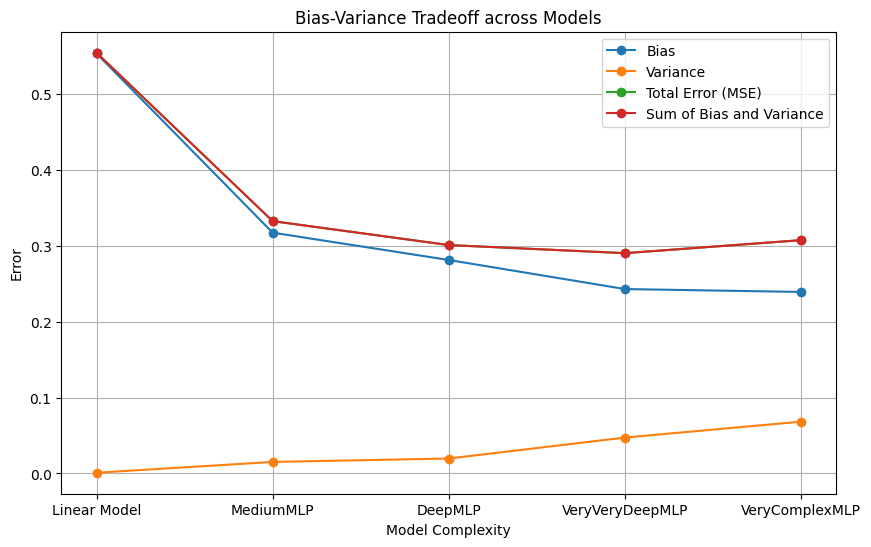

In [35]:
names = list(model_bias_variance.keys())
biases = [model_bias_variance[name]["bias"] for name in names]
variances = [model_bias_variance[name]["variance"] for name in names]
total_errors = [model_bias_variance[name]["total_error"] for name in names]
error_sums = [model_bias_variance[name]["error_sum"] for name in names]

plt.figure(figsize=(10,6))
plt.plot(names, biases, marker='o', label='Bias')
plt.plot(names, variances, marker='o', label='Variance')
plt.plot(names, total_errors, marker='o', label='Total Error (MSE)')
plt.plot(names, error_sums, marker='o', label='Sum of Bias and Variance')
plt.xlabel('Model Complexity')
plt.ylabel('Error')
plt.title('Bias-Variance Tradeoff across Models')
plt.legend()
plt.grid(True)
plt.show()

In [25]:
model_bias_variance

{'Linear Model': {'bias': np.float64(0.5539361915642891),
  'variance': np.float32(0.0009563449),
  'total_error': np.float64(0.5548925409055127),
  'error_sum': np.float64(0.554892536448178)},
 'MediumMLP': {'bias': np.float64(0.3175901169187821),
  'variance': np.float32(0.015181951),
  'total_error': np.float64(0.33277206700848766),
  'error_sum': np.float64(0.332772068143586)},
 'DeepMLP': {'bias': np.float64(0.28152094046700316),
  'variance': np.float32(0.01969459),
  'total_error': np.float64(0.30121552478962754),
  'error_sum': np.float64(0.3012155295454295)}}

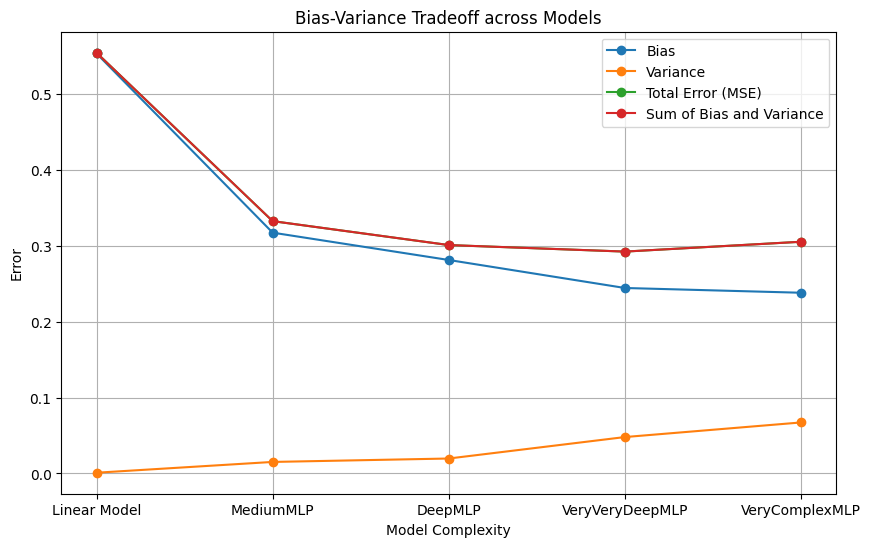

In [37]:
names = list(model_bias_variance.keys())
biases = [model_bias_variance[name]["bias"] for name in names]
variances = [model_bias_variance[name]["variance"] for name in names]
total_errors = [model_bias_variance[name]["total_error"] for name in names]
error_sums = [model_bias_variance[name]["error_sum"] for name in names]

plt.figure(figsize=(10,6))
plt.plot(names, biases, marker='o', label='Bias')
plt.plot(names, variances, marker='o', label='Variance')
plt.plot(names, total_errors, marker='o', label='Total Error (MSE)')
plt.plot(names, error_sums, marker='o', label='Sum of Bias and Variance')
plt.xlabel('Model Complexity')
plt.ylabel('Error')
plt.title('Bias-Variance Tradeoff across Models')
plt.legend()
plt.grid(True)
plt.show()